# Monte Carlo: устойчивость калибровок PD к составу портфеля

Проверяем, насколько результаты сравнения калибраторов зависят от конкретного сгенерированного портфеля. Логика:

- **RF и все калибраторы обучаются один раз** на полном in-time периоде 2020-2023 — внутри сценариев ничего не переобучается;
- каждый сценарий независимо берет **~80% наблюдений без возврата** отдельно из in-time и отдельно из OOT 2024;
- подвыборки прогоняются через уже готовый пайплайн `score -> calibrated PD -> EL / UL / Capital / RWA`;
- по каждому сценарию и методу считаются:
  - p-value биномиального теста на IN-TIME и на OOT (min binomial p-value по **фиксированным грейдам мастер-шкалы A1…E** — та же конструкция, что в разделе 8.4 основного ноутбука: тест считается **после присвоения рейтинга**, факт дефолтов в грейде против репрезентативного PD грейда, минимум по непустым грейдам);
  - средний PD на OOT;
  - Expected Loss, Unexpected Loss capital, их сумму **EL + UL** (полный экономический капитал) и RWA (те же допущения, что в разделе 8.1: EAD = 1 млн на актив, LGD = 40%, M = 2.5). Отдельная колонка Required Capital убрана: она тождественно равна UL (`required_capital = capital_ratio · RWA = UL`), поэтому вместо неё показываем EL + UL — это качественно другая, более содержательная величина.

Итоговая таблица показывает для каждого метода **среднее, минимум, максимум и разницу max-min** — чем уже разброс, тем меньше результат зависит от случайного состава портфеля.

Вычислительный движок лежит в `notebooks/monte_carlo.py`; этот ноутбук — его отчетная обертка с таблицами и графиками.

In [1]:
import sys

for extra_path in ("..", "."):
    if extra_path not in sys.path:
        sys.path.append(extra_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.ticker import PercentFormatter

from monte_carlo import (
    METRIC_COLUMNS,
    prepare_fixed_pipeline,
    run_scenario,
    summarize_monte_carlo,
    cross_method_spread,
    summarize_cross_method_spread,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11
COLORS = ["#e74c3c", "#2980b9", "#27ae60", "#e67e22", "#8e44ad", "#16a085"]

N_SCENARIOS = 1000
SAMPLE_FRAC = 0.8

print(f"Сценариев: {N_SCENARIOS} | доля подвыборки: {SAMPLE_FRAC:.0%}")

Сценариев: 1000 | доля подвыборки: 80%


## 1. Фиксированный пайплайн

Один раз генерируем тот же синтетический stress-портфель (random_state=42, как в основном ноутбуке), обучаем RF и все пять калибраторов на полном in-time. Дальше эти объекты не меняются.

In [2]:
pipeline = prepare_fixed_pipeline(portfolio="stress", random_state=42)

n_intime = len(pipeline["y_calib"])
n_oot = len(pipeline["y_test"])
ct_intime = float(pipeline["y_calib"].mean())
dr_oot = float(pipeline["y_test"].mean())

print(f"In-time (2020-2023): {n_intime:,} строк | ЦТ = {ct_intime:.2%}")
print(f"OOT (2024):          {n_oot:,} строк | фактическая доля дефолтов = {dr_oot:.2%}")
print(f"Размер сценарной подвыборки: ~{int(n_intime * SAMPLE_FRAC):,} in-time / ~{int(n_oot * SAMPLE_FRAC):,} OOT строк")
print(f"Методы: {', '.join(pipeline['methods'])}")
print("\nПер-строчные PD и IRB-капитал предвычислены один раз; сценарий только индексирует")
print("свою случайную ~80%-подвыборку — поэтому 1000 сценариев считаются за минуты.")

In-time (2020-2023): 31,224 строк | ЦТ = 4.81%
OOT (2024):          8,776 строк | фактическая доля дефолтов = 4.73%
Размер сценарной подвыборки: ~24,979 in-time / ~7,020 OOT строк
Методы: Логит-калибровка, Изотоническая регрессия, Бета-калибровка, Монотонный сплайн, Французский сплайн

Пер-строчные PD и IRB-капитал предвычислены один раз; сценарий только индексирует
свою случайную ~80%-подвыборку — поэтому 1000 сценариев считаются за минуты.


## 2. Прогон сценариев

Каждый сценарий использует свой seed (0..N-1), поэтому весь эксперимент воспроизводим. При 1000 сценариях таблица целиком (5000 строк) не нужна — ниже показаны первые 5 сценариев для наглядности формата, все данные лежат в `scenario_results`.

In [3]:
scenario_results = pd.concat(
    [run_scenario(pipeline, scenario_seed=seed, sample_frac=SAMPLE_FRAC) for seed in range(N_SCENARIOS)],
    ignore_index=True,
)

money_cols = ["expected_loss", "unexpected_loss_capital", "el_plus_ul", "rwa"]
scenario_view = scenario_results.copy()
for col in money_cols:
    scenario_view[col + "_bln"] = scenario_view[col] / 1e9
scenario_view = scenario_view.drop(columns=money_cols)

n_preview = 5 * scenario_results["method"].nunique()
print(f"Всего строк: {len(scenario_results)} ({N_SCENARIOS} сценариев x {scenario_results['method'].nunique()} методов)")
print(f"Ниже — первые 5 сценариев ({n_preview} строк):")
display(
    scenario_view.head(n_preview).style.format({
        "p_value_intime": "{:.6f}",
        "p_value_oot": "{:.6f}",
        "oot_mean_pd": "{:.4%}",
        "expected_loss_bln": "{:.4f}",
        "unexpected_loss_capital_bln": "{:.4f}",
        "el_plus_ul_bln": "{:.4f}",
        "rwa_bln": "{:.4f}",
    }).hide(axis="index")
)

Всего строк: 5000 (1000 сценариев x 5 методов)
Ниже — первые 5 сценариев (25 строк):


scenario,method,p_value_intime,p_value_oot,oot_mean_pd,expected_loss_bln,unexpected_loss_capital_bln,el_plus_ul_bln,rwa_bln
0,Логит-калибровка,0.059250,0.075998,4.8552%,0.1364,0.5413,0.6776,6.7658
0,Изотоническая регрессия,0.000000,0.000098,4.8438%,0.1361,0.5213,0.6573,6.5161
0,Бета-калибровка,0.018669,0.068054,4.8478%,0.1361,0.5474,0.6836,6.8426
0,Монотонный сплайн,0.000001,0.000106,4.8596%,0.1365,0.5249,0.6614,6.5619
0,Французский сплайн,0.000005,0.000695,4.8562%,0.1364,0.5249,0.6613,6.5606
1,Логит-калибровка,0.090599,0.074934,4.9548%,0.1392,0.5457,0.6848,6.8212
1,Изотоническая регрессия,0.000000,0.000001,4.9645%,0.1394,0.5263,0.6657,6.5782
1,Бета-калибровка,0.039909,0.150201,4.9469%,0.1389,0.5516,0.6906,6.8953
1,Монотонный сплайн,0.000000,0.000001,4.9699%,0.1396,0.5300,0.6696,6.6245
1,Французский сплайн,0.000000,0.000001,4.9653%,0.1395,0.5298,0.6693,6.6231


### Полная выгрузка всех сценариев

Все 1000 сценариев (5000 строк) сохраняются в `docs/monte_carlo_scenarios.csv`, чтобы с ними можно было ознакомиться отдельно — открыть в Excel или прямо на GitHub (там CSV показывается как таблица с поиском и сортировкой). Денежные метрики — в исходных единицах (рубли), `oot_mean_pd` и p-value — как доли.

In [4]:
from pathlib import Path

csv_path = Path("..") / "docs" / "monte_carlo_scenarios.csv"
export = scenario_results.sort_values(["scenario", "method"]).reset_index(drop=True)
export.to_csv(csv_path, index=False, encoding="utf-8-sig")

print(f"Сохранено {len(export)} строк ({export['scenario'].nunique()} сценариев x {export['method'].nunique()} методов)")
print(f"Файл: docs/monte_carlo_scenarios.csv")
print(f"Колонки: {', '.join(export.columns)}")

Сохранено 5000 строк (1000 сценариев x 5 методов)
Файл: docs/monte_carlo_scenarios.csv
Колонки: scenario, method, p_value_intime, p_value_oot, oot_mean_pd, expected_loss, unexpected_loss_capital, el_plus_ul, rwa


## 3. Итоговая таблица: среднее / минимум / максимум / разброс

Ключевой показатель — **range (max - min)**: он показывает, насколько сильно метрика гуляет между сценариями при неизменной модели и калибровке.

In [5]:
summary = summarize_monte_carlo(scenario_results)

metric_titles = {
    "p_value_intime": ("Min binomial p-value (мастер-шкала A1…E), IN-TIME", "{:.6f}"),
    "p_value_oot": ("Min binomial p-value (мастер-шкала A1…E), OOT", "{:.6f}"),
    "oot_mean_pd": ("Средний PD на OOT", "{:.4%}"),
    "expected_loss": ("Expected Loss, млрд", None),
    "unexpected_loss_capital": ("UL capital, млрд", None),
    "el_plus_ul": ("EL + UL (экономический капитал), млрд", None),
    "rwa": ("RWA, млрд", None),
}

for metric in METRIC_COLUMNS:
    title, fmt = metric_titles[metric]
    block = summary[["method"] + [f"{metric}_{s}" for s in ("mean", "min", "max", "range")]].copy()
    block.columns = ["method", "mean", "min", "max", "range (max-min)"]
    if fmt is None:
        for col in ("mean", "min", "max", "range (max-min)"):
            block[col] = block[col] / 1e9
        fmt = "{:.4f}"
    print(title)
    display(block.style.format({c: fmt for c in ("mean", "min", "max", "range (max-min)")}).hide(axis="index"))

Min binomial p-value (мастер-шкала A1…E), IN-TIME


method,mean,min,max,range (max-min)
Бета-калибровка,0.024351,0.000023,0.123142,0.123119
Изотоническая регрессия,0.000000,0.000000,0.000022,0.000022
Логит-калибровка,0.089304,0.000682,0.363561,0.362879
Монотонный сплайн,0.000000,0.000000,0.000027,0.000027
Французский сплайн,0.000005,0.000000,0.000202,0.000202


Min binomial p-value (мастер-шкала A1…E), OOT


method,mean,min,max,range (max-min)
Бета-калибровка,0.082136,0.001176,0.361925,0.360748
Изотоническая регрессия,0.000419,0.000000,0.082560,0.082560
Логит-калибровка,0.073829,0.001379,0.347654,0.346275
Монотонный сплайн,0.000384,0.000000,0.045910,0.045910
Французский сплайн,0.000990,0.000001,0.087312,0.087311


Средний PD на OOT


...

method,mean,min,max,range (max-min)
Бета-калибровка,0.5490,0.5444,0.5528,0.0085
Изотоническая регрессия,0.5234,0.5184,0.5282,0.0098
Логит-калибровка,0.5430,0.5382,0.5470,0.0088
Монотонный сплайн,0.5271,0.5221,0.5318,0.0096
Французский сплайн,0.5269,0.5220,0.5316,0.0096


EL + UL (экономический капитал), млрд


method,mean,min,max,range (max-min)
Бета-калибровка,0.6867,0.6776,0.6963,0.0187
Изотоническая регрессия,0.6614,0.6520,0.6714,0.0194
Логит-калибровка,0.6809,0.6716,0.6906,0.0190
Монотонный сплайн,0.6652,0.6561,0.6751,0.0190
Французский сплайн,0.6650,0.6558,0.6749,0.0191


RWA, млрд


method,mean,min,max,range (max-min)
Бета-калибровка,6.8631,6.8048,6.9105,0.1058
Изотоническая регрессия,6.5422,6.4799,6.6027,0.1227
Логит-калибровка,6.7877,6.7278,6.8373,0.1095
Монотонный сплайн,6.5881,6.5268,6.6469,0.1201
Французский сплайн,6.5866,6.5249,6.6444,0.1195


## 3a. Межметодный разброс EL + UL внутри одного сценария

Сводка выше меряет разброс **одного метода по 1000 сценариев**. Здесь — ортогональный срез: внутри **одного** сценария (одна фиксированная ~80%-подвыборка, все 5 методов оценивают одних и тех же заёмщиков) насколько далеко методы расходятся по полному экономическому капиталу EL + UL?

Для каждого сценария берём самый дешёвый и самый дорогой по EL + UL метод, абсолютную разницу `max − min` и относительную `(max − min) / min` — то есть на сколько процентов самый консервативный метод требует больше капитала, чем самый экономный, при **одном и том же портфеле**. Таблица — одна строка на сценарий (транспонированная ориентация), все 1000 строк выгружаются в `docs/monte_carlo_cross_method_spread.csv`.

In [6]:
spread = cross_method_spread(scenario_results)
spread_stats, spread_counts = summarize_cross_method_spread(spread)

spread_csv_path = Path("..") / "docs" / "monte_carlo_cross_method_spread.csv"
spread.to_csv(spread_csv_path, index=False, encoding="utf-8-sig")

spread_view = spread.assign(
    min_el_plus_ul_bln=lambda d: d["min_el_plus_ul"] / 1e9,
    max_el_plus_ul_bln=lambda d: d["max_el_plus_ul"] / 1e9,
    abs_diff_bln=lambda d: d["abs_diff"] / 1e9,
)[["scenario", "min_method", "max_method", "min_el_plus_ul_bln", "max_el_plus_ul_bln", "abs_diff_bln", "rel_diff"]]

print(f"Первые 8 сценариев из {spread['scenario'].nunique()} (полная таблица — docs/monte_carlo_cross_method_spread.csv):")
display(
    spread_view.head(8).style.format({
        "min_el_plus_ul_bln": "{:.4f}",
        "max_el_plus_ul_bln": "{:.4f}",
        "abs_diff_bln": "{:.4f}",
        "rel_diff": "{:.4%}",
    }).hide(axis="index")
)

abs_summary = (spread_stats.loc[spread_stats["quantity"] == "abs_diff", ["mean", "median", "min", "max"]] / 1e9).copy()
abs_summary.insert(0, "показатель", "abs (max − min), млрд")
rel_summary = spread_stats.loc[spread_stats["quantity"] == "rel_diff", ["mean", "median", "min", "max"]].copy()
rel_summary.insert(0, "показатель", "rel (max − min) / min")

print("\nСводка межметодного разброса EL + UL по всем сценариям:")
display(abs_summary.style.format({c: "{:.4f}" for c in ("mean", "median", "min", "max")}).hide(axis="index"))
display(rel_summary.style.format({c: "{:.4%}" for c in ("mean", "median", "min", "max")}).hide(axis="index"))

print("Как часто метод оказывался самым дешёвым / самым дорогим по EL + UL:")
display(spread_counts.style.format({"times_cheapest": "{:.0f}", "times_most_expensive": "{:.0f}"}).hide(axis="index"))

Первые 8 сценариев из 1000 (полная таблица — docs/monte_carlo_cross_method_spread.csv):


scenario,min_method,max_method,min_el_plus_ul_bln,max_el_plus_ul_bln,abs_diff_bln,rel_diff
0,Изотоническая регрессия,Бета-калибровка,0.6573,0.6836,0.0262,3.9868%
1,Изотоническая регрессия,Бета-калибровка,0.6657,0.6906,0.0249,3.7330%
2,Изотоническая регрессия,Бета-калибровка,0.6677,0.6927,0.0250,3.7513%
3,Изотоническая регрессия,Бета-калибровка,0.6616,0.6871,0.0255,3.8601%
4,Изотоническая регрессия,Бета-калибровка,0.6648,0.6896,0.0248,3.7345%
5,Изотоническая регрессия,Бета-калибровка,0.6572,0.6829,0.0257,3.9090%
6,Изотоническая регрессия,Бета-калибровка,0.6606,0.6861,0.0255,3.8544%
7,Изотоническая регрессия,Бета-калибровка,0.6582,0.6839,0.0257,3.9070%



Сводка межметодного разброса EL + UL по всем сценариям:


показатель,mean,median,min,max
"abs (max − min), млрд",0.0254,0.0254,0.0239,0.0268


показатель,mean,median,min,max
rel (max − min) / min,3.8386%,3.8385%,3.5824%,4.0889%


Как часто метод оказывался самым дешёвым / самым дорогим по EL + UL:


method,times_cheapest,times_most_expensive
Бета-калибровка,0,1000
Изотоническая регрессия,1000,0


## 3b. Доля сценариев со значимым биномиальным тестом

С 1000 сценариев можно оценить не отдельные p-value, а **как часто** тест значим на 5% уровне. Тест — на фиксированных грейдах мастер-шкалы A1…E (после присвоения рейтинга), как в разделе 8.4. Если у метода тест значим почти во всех сценариях — это устойчивый структурный сигнал разладки на OOT, а не случайность одной подвыборки.

In [7]:
alpha_level = 0.05
sig_share = (
    scenario_results
    .assign(
        sig_intime=lambda d: d["p_value_intime"] < alpha_level,
        sig_oot=lambda d: d["p_value_oot"] < alpha_level,
    )
    .groupby("method")
    .agg(
        share_sig_intime=("sig_intime", "mean"),
        share_sig_oot=("sig_oot", "mean"),
        median_p_oot=("p_value_oot", "median"),
    )
    .reset_index()
    .sort_values("share_sig_oot", ascending=False)
)

display(
    sig_share.style.format({
        "share_sig_intime": "{:.1%}",
        "share_sig_oot": "{:.1%}",
        "median_p_oot": "{:.6f}",
    }).hide(axis="index")
)
print(f"share_sig_* — доля из {N_SCENARIOS} сценариев, где min binomial p-value < {alpha_level:.0%}.")

method,share_sig_intime,share_sig_oot,median_p_oot
Монотонный сплайн,100.0%,100.0%,0.000013
Изотоническая регрессия,100.0%,99.9%,0.000012
Французский сплайн,100.0%,99.8%,0.000090
Логит-калибровка,28.3%,37.8%,0.058393
Бета-калибровка,91.3%,22.7%,0.070266


share_sig_* — доля из 1000 сценариев, где min binomial p-value < 5%.


## 3c. Что стоит за значимостью: диагностика худшего грейда

Высокая доля значимых сценариев сама по себе может ввести в заблуждение — важно понять, **что именно** делает тест значимым. Для каждого метода находим **грейд мастер-шкалы** с минимальным p-value и смотрим: какой это грейд (низкий «безопасный» или средний), какой у него репрезентативный PD, какая фактическая частота дефолта и насколько велик абсолютный разрыв. Считаем по 50 сценариям — этого достаточно, чтобы охарактеризовать паттерн.

In [8]:
from scipy.stats import binomtest
from collections import Counter
from monte_carlo import _master_scale_representative_pd
from src.portfolio import MASTER_SCALE_RATINGS

N_DIAG_SCENARIOS = 50
representative_pd = _master_scale_representative_pd()
grade_names = np.array(MASTER_SCALE_RATINGS)

def worst_grade_diagnostics(pipeline, n_scenarios=N_DIAG_SCENARIOS, sample_frac=SAMPLE_FRAC):
    # Мирроринг master_scale_min_binomial_p_value, но с сохранением деталей худшего грейда.
    y_test = pipeline["y_test"]
    n_grades = len(representative_pd)
    rows = []
    for method in pipeline["methods"]:
        grades_full = pipeline["grade_test_full"][method]
        worst_grade, rep_pd, obs_rate, abs_gap, min_p = [], [], [], [], []
        for seed in range(n_scenarios):
            rng = np.random.default_rng(seed)
            idx = rng.choice(len(y_test), size=int(round(len(y_test) * sample_frac)), replace=False)
            g = grades_full[idx]
            y = y_test[idx]
            n = np.bincount(g, minlength=n_grades).astype(float)
            d = np.bincount(g, weights=y, minlength=n_grades)
            cand = [
                (gr, binomtest(int(round(d[gr])), int(round(n[gr])), float(representative_pd[gr])).pvalue)
                for gr in range(n_grades) if n[gr] > 0
            ]
            gr, p = min(cand, key=lambda t: t[1])
            worst_grade.append(gr)
            rep_pd.append(representative_pd[gr])
            obs_rate.append(d[gr] / n[gr])
            abs_gap.append(abs(d[gr] / n[gr] - representative_pd[gr]))
            min_p.append(p)
        mode_gr = Counter(worst_grade).most_common(1)[0][0]
        rows.append({
            "method": method,
            "worst_grade_mode": grade_names[mode_gr],
            "worst_grade_rep_pd": float(np.mean(rep_pd)),
            "worst_grade_obs_rate": float(np.mean(obs_rate)),
            "worst_grade_abs_gap": float(np.mean(abs_gap)),
            "median_min_p": float(np.median(min_p)),
        })
    return pd.DataFrame(rows).sort_values("median_min_p")

worst_diag = worst_grade_diagnostics(pipeline)
display(
    worst_diag.style.format({
        "worst_grade_rep_pd": "{:.3%}",
        "worst_grade_obs_rate": "{:.3%}",
        "worst_grade_abs_gap": "{:.2%}",
        "median_min_p": "{:.2e}",
    }).hide(axis="index")
)
print(f"По {N_DIAG_SCENARIOS} сценариям. worst_grade_mode — грейд, который чаще всего оказывался худшим;")
print("worst_grade_abs_gap — средний |факт − репрезентативный PD грейда| в этом грейде.")

method,worst_grade_mode,worst_grade_rep_pd,worst_grade_obs_rate,worst_grade_abs_gap,median_min_p
Изотоническая регрессия,B1,0.149%,0.939%,0.83%,1.11e-05
Монотонный сплайн,B1,0.149%,0.929%,0.81%,1.23e-05
Французский сплайн,B1,0.353%,1.000%,0.80%,4.78e-05
Логит-калибровка,B3,2.224%,1.856%,0.80%,5.84e-02
Бета-калибровка,C2,2.062%,1.584%,0.77%,7.17e-02


По 50 сценариям. worst_grade_mode — грейд, который чаще всего оказывался худшим;
worst_grade_abs_gap — средний |факт − репрезентативный PD грейда| в этом грейде.


**Как это читать (важно, чтобы не сделать неверный вывод).**

- У **изотоники и обоих сплайнов** худший грейд — почти всегда «безопасный» **B1** (репрезентативный PD грейда порядка 0.15–0.35%): туда попадают заёмщики, которые на OOT дефолтят примерно на 0.9–1.0%. Абсолютный разрыв меньше процентного пункта, но относительно крошечного PD грейда это ошибка в разы, и при малом ожидаемом p биномиальный тест реагирует крайне резко (дисперсия `p(1-p)/n` ничтожна) — медианный min p-value порядка 1e-5.
- У **логита и беты** худший грейд «плавает» на более высоких PD (**B3 / C2**, репрезентативный PD ~2%). Абсолютный разрыв там сопоставим (~0.8 п.п.), но p-value заметно мягче (медиана ~0.06, то есть тест часто вообще **не** значим на 5%) — при более высокой PD грейда тот же разрыв статистически безобиднее.

То есть разница в доле значимых сценариев — это про то, **в какой грейд мастер-шкалы метод кладёт безопасный хвост**, а не про то, что сплайны экономически хуже.

## 4. Визуализация разброса

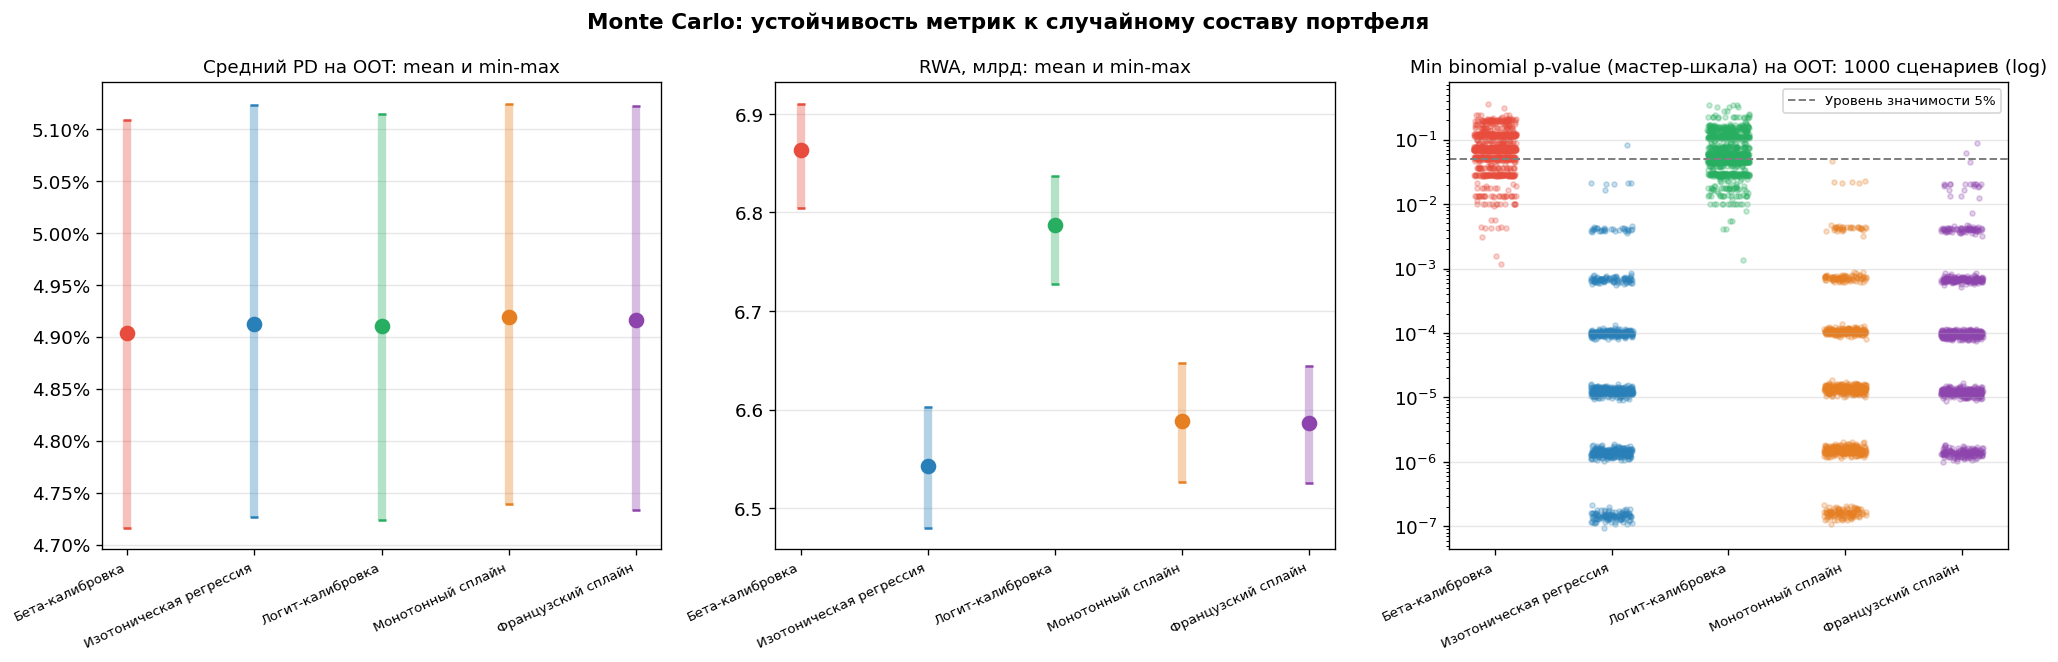

In [9]:
methods = list(summary["method"])
method_colors = {name: COLORS[i % len(COLORS)] for i, name in enumerate(methods)}

fig, axes = plt.subplots(1, 3, figsize=(17, 5.6))

def range_panel(ax, metric, title, scale=1.0, formatter=None):
    for i, name in enumerate(methods):
        row = summary.loc[summary["method"] == name].iloc[0]
        mean = row[f"{metric}_mean"] / scale
        lo = row[f"{metric}_min"] / scale
        hi = row[f"{metric}_max"] / scale
        color = method_colors[name]
        ax.vlines(i, lo, hi, color=color, lw=5, alpha=0.35)
        ax.scatter([i], [mean], color=color, s=70, zorder=5)
        ax.scatter([i, i], [lo, hi], color=color, s=28, marker="_", zorder=5)
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels(methods, rotation=25, ha="right", fontsize=8)
    ax.set_title(title, fontsize=11)
    if formatter is not None:
        ax.yaxis.set_major_formatter(formatter)
    ax.grid(axis="y", alpha=0.3)

range_panel(axes[0], "oot_mean_pd", "Средний PD на OOT: mean и min-max", formatter=PercentFormatter(1.0, decimals=2))
range_panel(axes[1], "rwa", "RWA, млрд: mean и min-max", scale=1e9)

ax = axes[2]
jitter_rng = np.random.default_rng(0)
for i, name in enumerate(methods):
    vals = scenario_results.loc[scenario_results["method"] == name, "p_value_oot"].to_numpy()
    vals = np.clip(vals, 1e-12, None)
    jitter = jitter_rng.uniform(-0.18, 0.18, len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals, color=method_colors[name], s=9, alpha=0.25)
ax.axhline(0.05, color="gray", linestyle="--", lw=1.2, label="Уровень значимости 5%")
ax.set_yscale("log")
ax.set_xticks(range(len(methods)))
ax.set_xticklabels(methods, rotation=25, ha="right", fontsize=8)
ax.set_title(f"Min binomial p-value (мастер-шкала) на OOT: {len(vals)} сценариев (log)", fontsize=11)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

plt.suptitle("Monte Carlo: устойчивость метрик к случайному составу портфеля", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Интерпретация

- **Средний PD на OOT и денежные метрики (EL / UL / EL+UL / RWA) устойчивы**: разброс max-min составляет доли процента от уровня метрики. Выводы раздела 8 основного ноутбука не зависят от того, какие именно ~80% портфеля попали в выборку.
- **Межметодный разброс EL + UL внутри сценария невелик** (раздел 3a): при одном и том же портфеле полный экономический капитал у самого консервативного и самого экономного метода различается на единицы процентов — выбор калибратора не переворачивает капитальную картину.
- **Биномиальный тест на OOT ведет себя по-разному у разных методов.** Тест теперь на фиксированных грейдах мастер-шкалы A1…E (после присвоения рейтинга) — как в разделе 8.4. Широкий разброс p-value ожидаем: min binomial p-value чувствителен к случайному числу дефолтов в отдельном грейде. Структурный сигнал — это когда p-value значим на **всех** сценариях (максимум по сценариям около нуля), а не только в среднем.
- На IN-TIME картина обратная у методов с точной подгонкой уровня: у них p-value заметно выше, потому что fit-выборка — это та же популяция, на которой откалиброван уровень PD.
- Таблица из раздела 3b (доля сценариев со значимым тестом) переводит это в одну цифру на метод: устойчивый структурный сигнал — это доля близкая к 100%, а разовые срабатывания — низкая доля.

**Почему НЕ стоит читать «100% значимых» как «метод сломан» (см. раздел 3c).** Тут работают три эффекта сразу, и их важно держать в голове:

1. **Тест перемощён при таком объёме** и берётся минимум по непустым грейдам A1…E без поправки на множественную проверку. При большом числе наблюдений в грейде даже разрыв меньше процентного пункта становится статистически значимым. Это известное свойство биномиальных тестов калибровки: на больших выборках они почти всегда отвергают. Поэтому абсолютная величина p-value (1e-5…1e-6) сильно преувеличивает практическую серьёзность.
2. **В синтетике заложен реальный OOT-сдвиг** (`oot_pd_lift` на 2024 в `data/generate_data.py`), а калибраторы намеренно не дотюниваются к фактической OOT-ЦТ. Поэтому какая-то реальная разладка на OOT ожидаема **по построению** — это не дефект калибратора, а свойство эксперимента.
3. **Разница между методами — про безопасный хвост, а не про капитал** (раздел 3c): изотоника и сплайны кладут самых надёжных заёмщиков в низкий грейд B1, где репрезентативный PD крошечный и тест гиперчувствителен. Экономические же метрики (средний PD, EL+UL, RWA) у всех методов близки и устойчивы — практический вывод несёт именно этот блок, а p-value стоит трактовать как guardrail локальной надёжности, а не как приговор методу.

**Про производительность.** RF-скоринг, по-строчный IRB-капитал и грейды мастер-шкалы предвычислены один раз в `prepare_fixed_pipeline`; сценарий только индексирует свою случайную ~80%-подвыборку и суммирует. 1000 ранов считаются за минуты.